## TASK # 1

Skewness: 12.97275234181623
Mean: 229.85800083049833
Median: 54.489999999999995


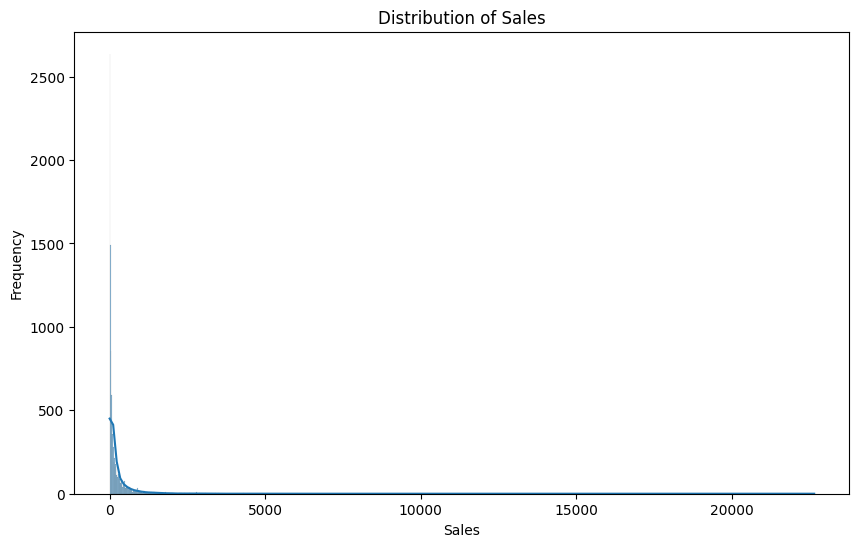

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/sample_data/Sample - Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])

skewness = df['Sales'].skew()
mean_sales = df['Sales'].mean()
median_sales = df['Sales'].median()

print("Skewness:", skewness)
print("Mean:", mean_sales)
print("Median:", median_sales)

plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], kde=True)
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.title('Distribution of Sales')
plt.show()

The sales distribution is right-skewed, with a longer tail toward higher values. The mean is greater than the median, so the median is generally a better summary of a typical sale.

## TASK # 2

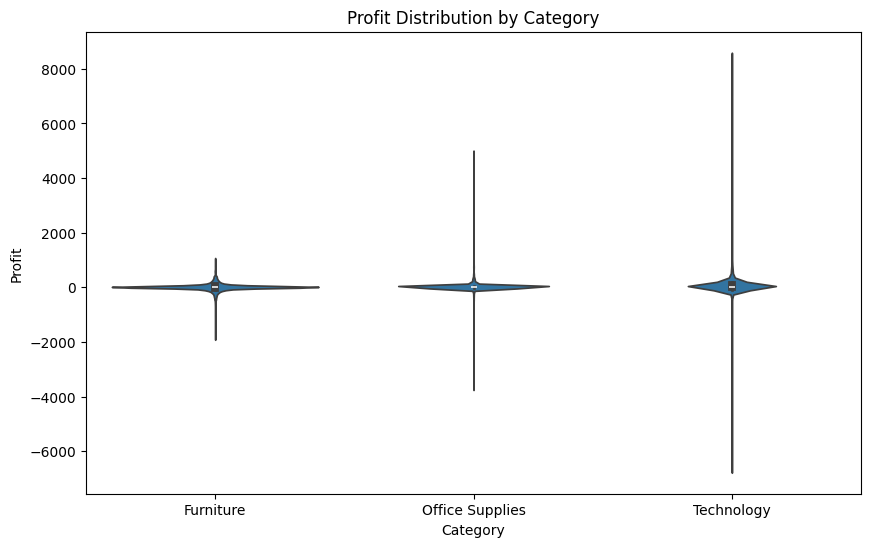

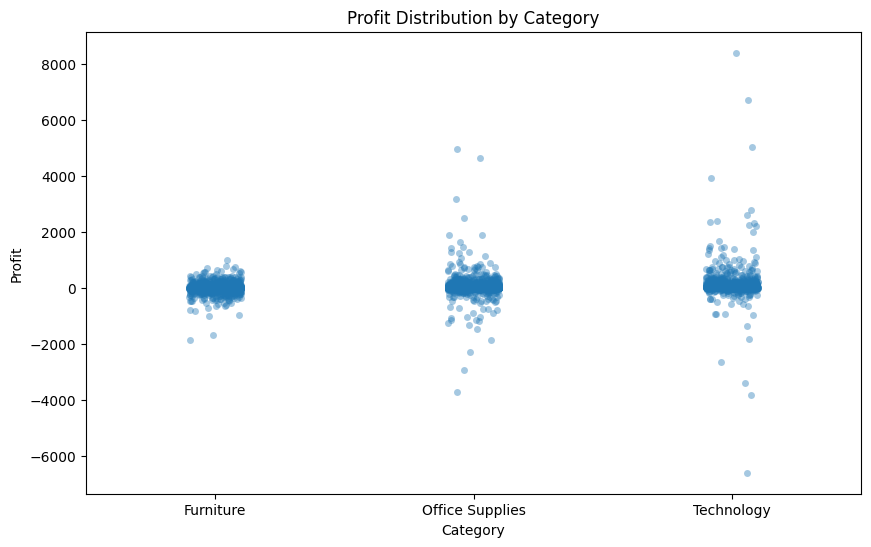

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Category', y='Profit')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.title('Profit Distribution by Category')
plt.show()

plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x='Category', y='Profit', jitter=True, alpha=0.4)
plt.xlabel('Category')
plt.ylabel('Profit')
plt.title('Profit Distribution by Category')
plt.show()

The violin plot better reveals bimodal or unusually spread-out distributions because it shows the full estimated density and shape of profit within each category.

## TASK # 3

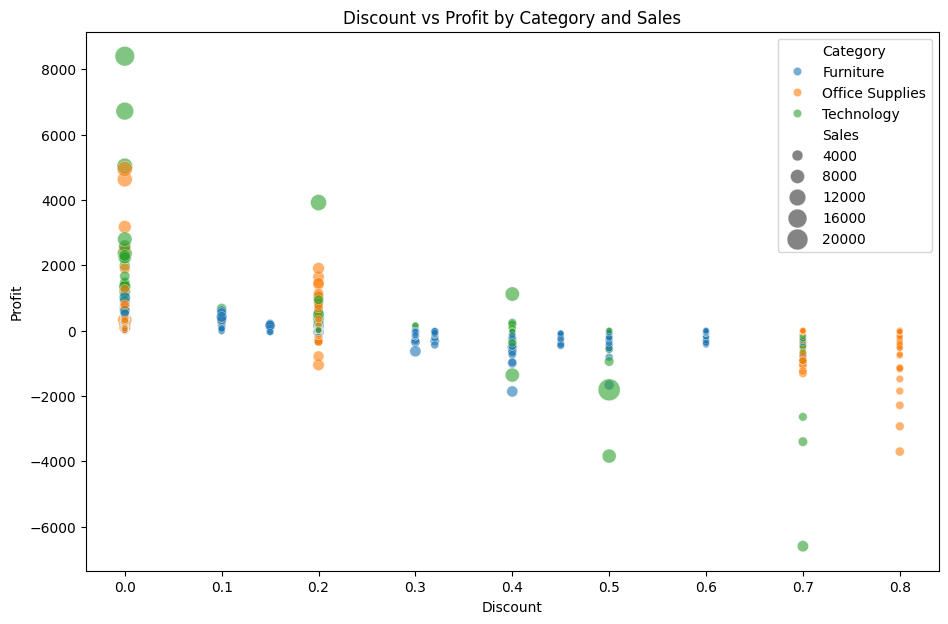

In [ ]:
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category',
    size='Sales',
    sizes=(20, 250),
    alpha=0.6
)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit by Category and Sales')
plt.show()

The four-variable encoding reveals how larger sales transactions are distributed across discount levels and categories, making it easier to see whether high-sales orders tend to have larger losses at higher discounts.

## TASK # 4

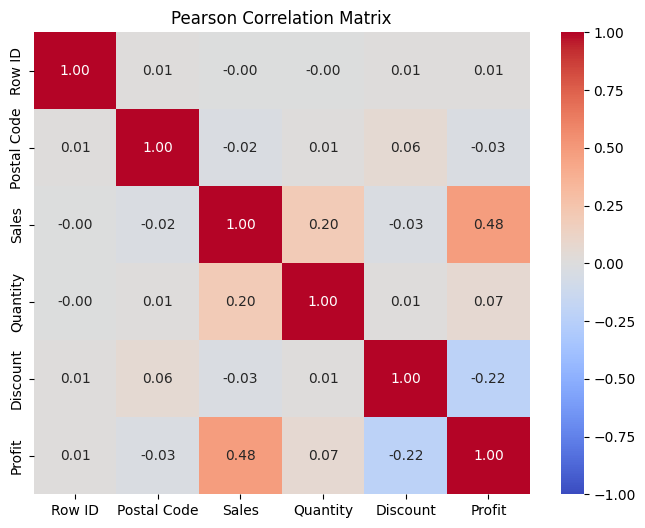

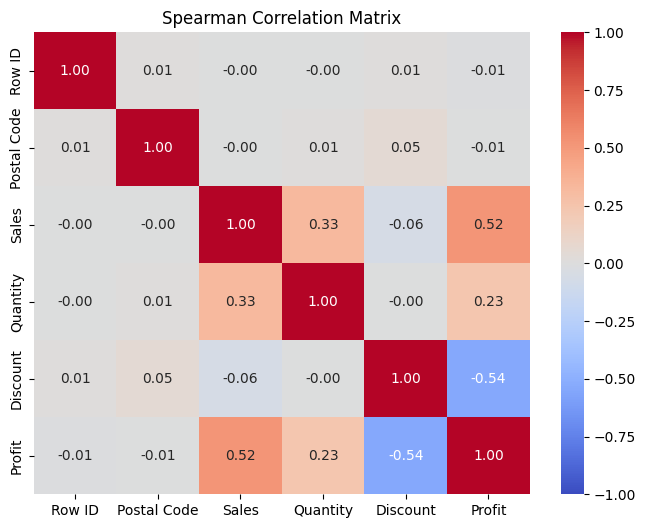

Pair with largest difference: ('Discount', 'Profit')
Difference: 0.32386272585885323


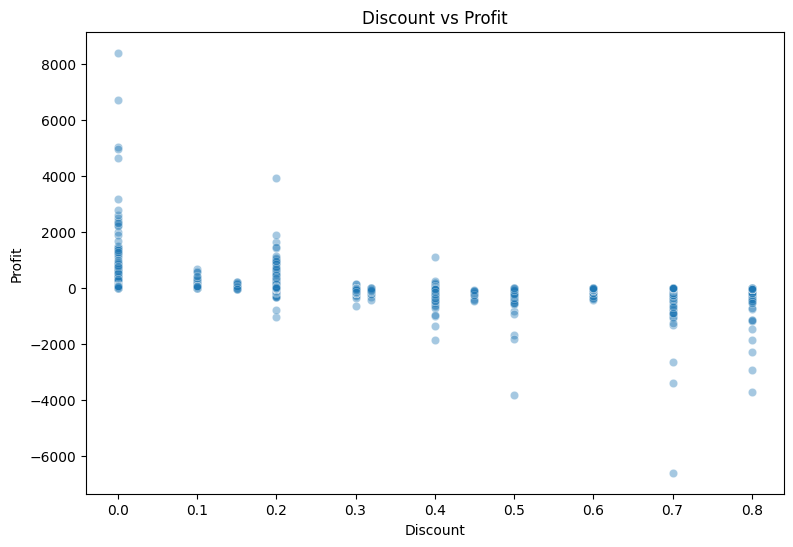

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

pearson_corr = df[numeric_cols].corr(method='pearson')
spearman_corr = df[numeric_cols].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Pearson Correlation Matrix')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Spearman Correlation Matrix')
plt.show()

corr_diff = (pearson_corr - spearman_corr).abs()
for col in corr_diff.columns:
    corr_diff.loc[col, col] = 0

pair = corr_diff.stack().idxmax()
difference = corr_diff.loc[pair[0], pair[1]]

print("Pair with largest difference:", pair)
print("Difference:", difference)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x=pair[0], y=pair[1], alpha=0.4)
plt.xlabel(pair[0])
plt.ylabel(pair[1])
plt.title(f'{pair[0]} vs {pair[1]}')
plt.show()


The Pearson and Spearman correlations can differ because Pearson measures linear association using the original values, while Spearman measures monotonic association using ranks and is less affected by outliers. \
Correlation does not imply causation; two variables may move together because of a third variable, coincidence, or another underlying relationship.

## TASK # 5

Category,Furniture,Office Supplies,Technology,All
Region,,,,
Central,163797.1638,167026.415,170416.312,5.012399e+05
East,208291.2040,205516.055,264973.981,6.787812e+05
South,117298.6840,125651.313,148771.908,3.917219e+05
West,252612.7435,220853.249,251991.832,7.254578e+05
All,741999.7953,719047.032,836154.033,2.297201e+06


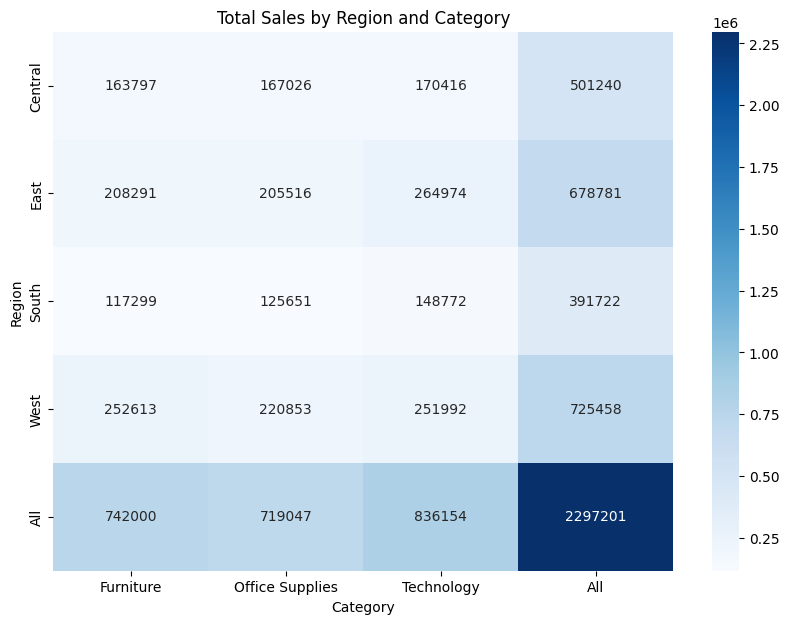

Highest revenue combination: ('East', 'Technology')
Total sales: 264973.981


In [ ]:
pivot = pd.pivot_table(
    df,
    index='Region',
    columns='Category',
    values='Sales',
    aggfunc='sum',
    margins=True
)

display(pivot)

plt.figure(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues')
plt.xlabel('Category')
plt.ylabel('Region')
plt.title('Total Sales by Region and Category')
plt.show()

region_category = pivot.iloc[:-1, :-1].stack().idxmax()
highest_sales = pivot.iloc[:-1, :-1].stack().max()

print("Highest revenue combination:", region_category)
print("Total sales:", highest_sales)

## TASK # 6

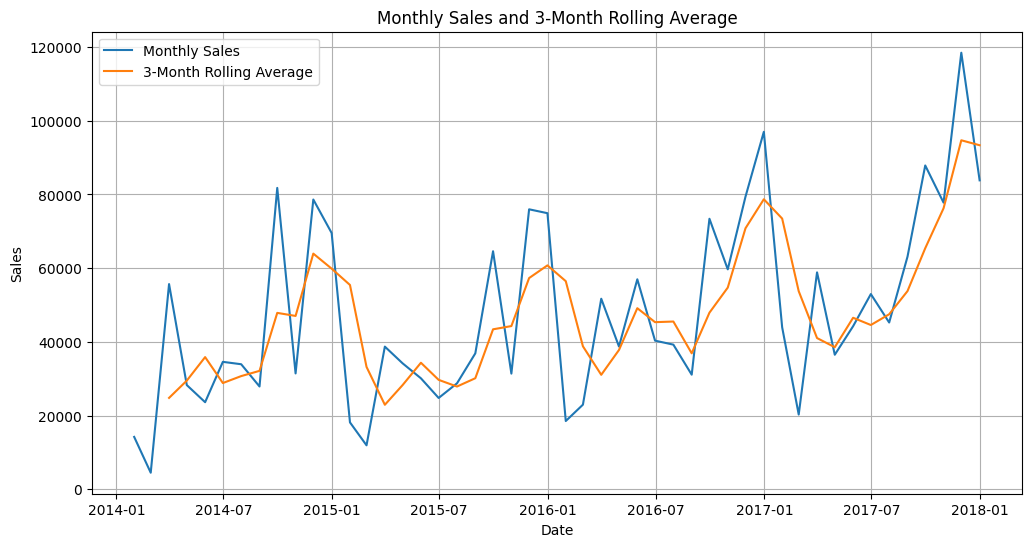

In [ ]:
time_df = df.set_index('Order Date')

monthly = time_df['Sales'].resample('ME').sum()
rolling = monthly.rolling(window=3).mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly.index, monthly.values, label='Monthly Sales')
plt.plot(rolling.index, rolling.values, label='3-Month Rolling Average')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Monthly Sales and 3-Month Rolling Average')
plt.legend()
plt.grid(True)
plt.show()

The 3-month rolling average smooths short-term month-to-month fluctuations and makes the underlying sales trend easier to see. \
It reduces noise in the raw monthly series, making sustained increases or decreases more apparent.

## TASK # 7

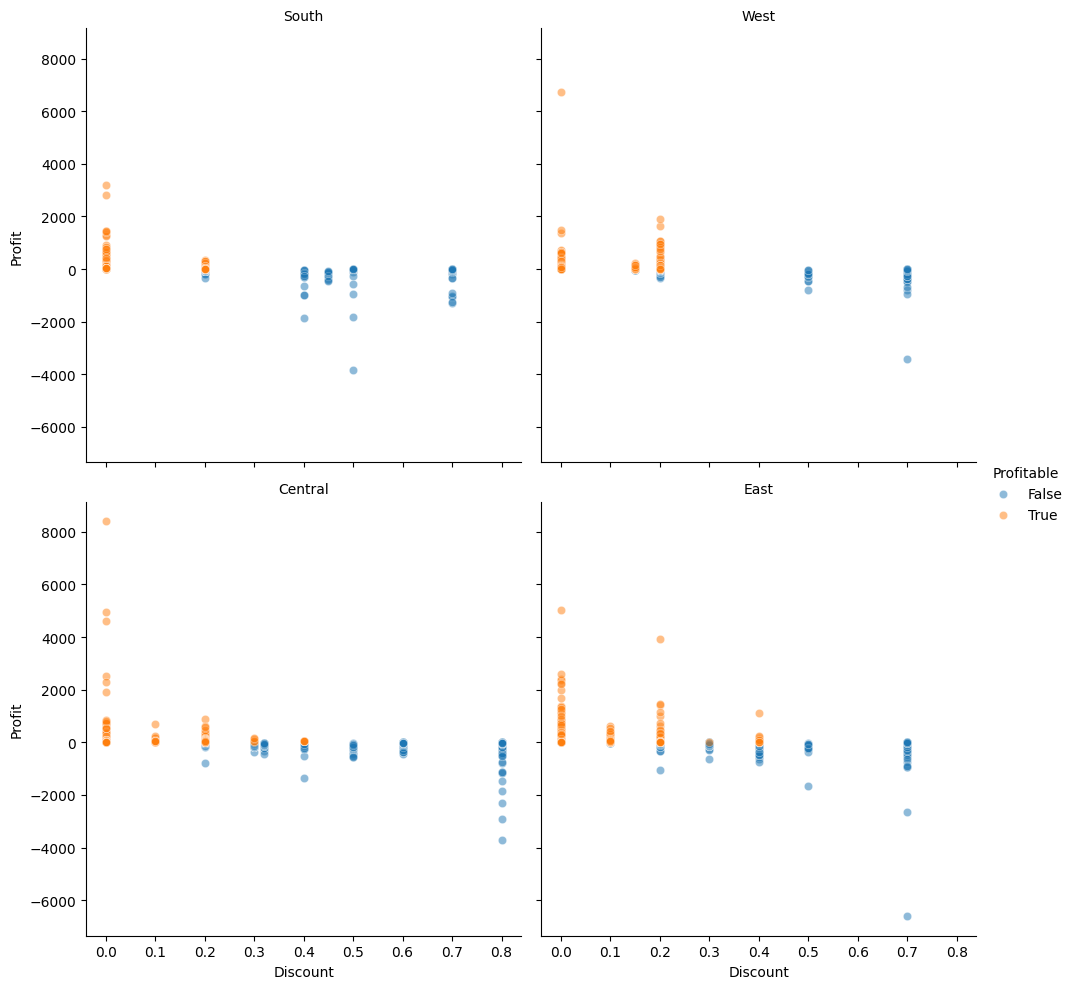

In [ ]:
df['Profitable'] = df['Profit'] > 0

g = sns.FacetGrid(
    df,
    col='Region',
    hue='Profitable',
    col_wrap=2,
    height=5
)
g.map_dataframe(
    sns.scatterplot,
    x='Discount',
    y='Profit',
    alpha=0.5
)
g.add_legend(title='Profitable')
g.set_axis_labels('Discount', 'Profit')
g.set_titles('{col_name}')
plt.show()

The West region shows a visibly different discount-profit relationship compared with the other regions, with higher discounts more clearly associated with negative profit.

## TASK 8

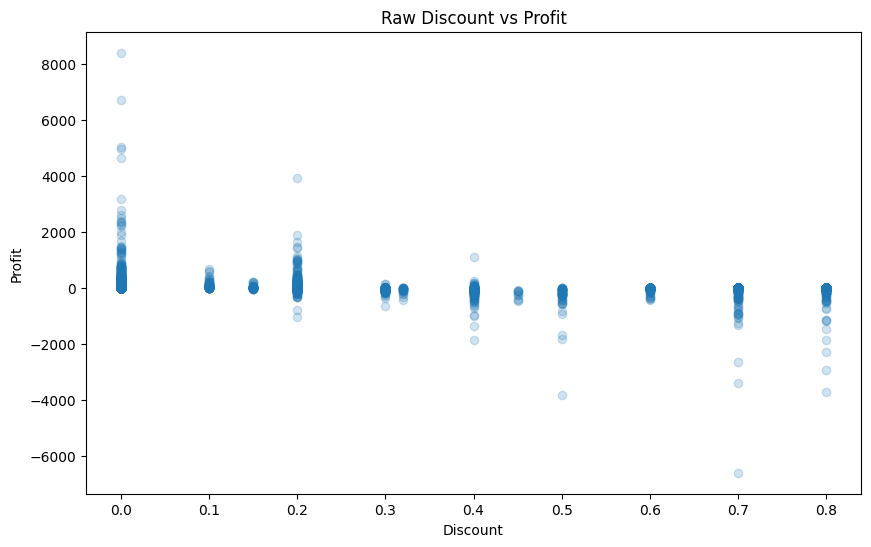

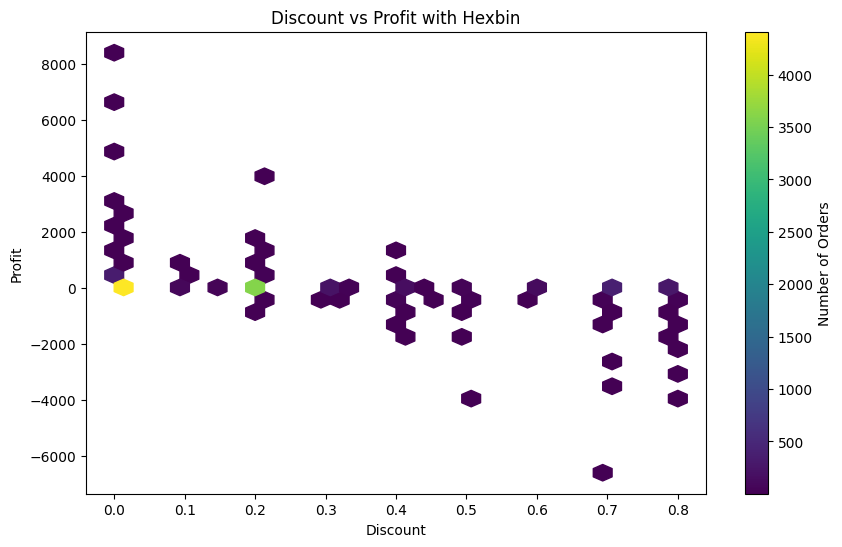

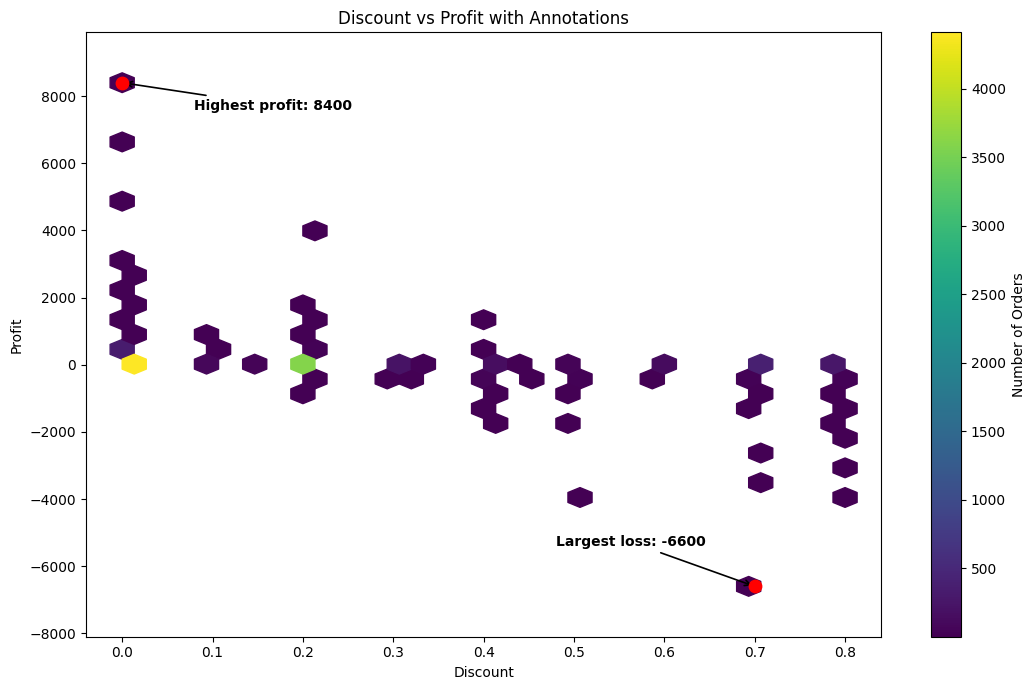

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.2)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Raw Discount vs Profit')
plt.show()

plt.figure(figsize=(10, 6))
plt.hexbin(df['Discount'], df['Profit'], gridsize=30, mincnt=1, cmap='viridis')
plt.colorbar(label='Number of Orders')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit with Hexbin')
plt.show()

best = df.loc[df['Profit'].idxmax()]
worst = df.loc[df['Profit'].idxmin()]

plt.figure(figsize=(11, 7))
plt.hexbin(df['Discount'], df['Profit'], gridsize=30, mincnt=1, cmap='viridis')
plt.colorbar(label='Number of Orders')

plt.scatter(best['Discount'], best['Profit'], color='red', s=80, zorder=5)
plt.annotate(
    f"Highest profit: {best['Profit']:.0f}",
    xy=(best['Discount'], best['Profit']),
    xytext=(best['Discount'] + 0.08, best['Profit'] - 800),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
    fontsize=10,
    fontweight='bold'
)

plt.scatter(worst['Discount'], worst['Profit'], color='red', s=80, zorder=5)
plt.annotate(
    f"Largest loss: {worst['Profit']:.0f}",
    xy=(worst['Discount'], worst['Profit']),
    xytext=(worst['Discount'] - 0.22, worst['Profit'] + 1200),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
    fontsize=10,
    fontweight='bold'
)

plt.ylim(df['Profit'].min() - 1500, df['Profit'].max() + 1500)

plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit with Annotations')
plt.tight_layout()
plt.show()

Hexbin is suitable because the large number of order-level points causes heavy overplotting, while hexbin shows the density of observations clearly.